In [1]:
# client_geotikzbridge.py / notebook cells
# Tests your FastAPI endpoint:
# POST http://127.0.0.1:8007/geotikzbridge

from pathlib import Path
import json
import requests
from PIL import Image, ImageDraw
from IPython.display import display, Markdown, Image as IPyImage

In [2]:
# Configuration

BASE_URL = "http://127.0.0.1:8007"
HEALTH_URL = f"{BASE_URL}/health"
PREDICT_URL = f"{BASE_URL}/geotikzbridge"

# Increase if inference is slow.
REQUEST_TIMEOUT_SECONDS = 600

print("Health URL:", HEALTH_URL)
print("Predict URL:", PREDICT_URL)

Health URL: http://127.0.0.1:8007/health
Predict URL: http://127.0.0.1:8007/geotikzbridge


Saved test image to: /home/jonas/PycharmProjects/tikzcodegenerator/evaluation/models/geotikzbridge-base-8b/geotikzbridge_test.png


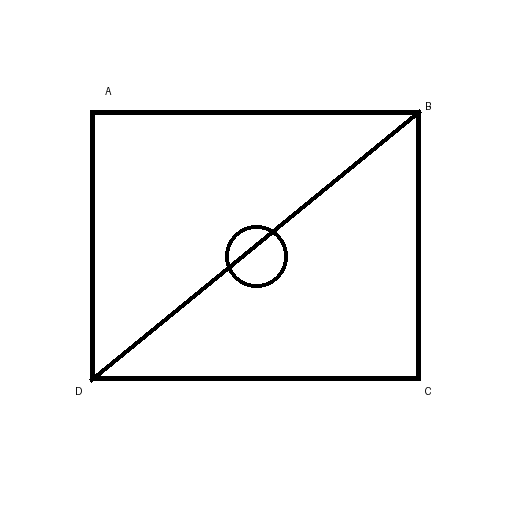

In [3]:
# Create a simple test image

IMAGE_PATH = Path("geotikzbridge_test.png")

img = Image.new("RGB", (512, 512), "white")
draw = ImageDraw.Draw(img)

draw.rectangle((90, 110, 420, 380), outline="black", width=5)
draw.line((90, 380, 420, 110), fill="black", width=4)
draw.ellipse((225, 225, 287, 287), outline="black", width=4)

draw.text((105, 85), "A", fill="black")
draw.text((425, 100), "B", fill="black")
draw.text((425, 385), "C", fill="black")
draw.text((75, 385), "D", fill="black")

img.save(IMAGE_PATH)

print("Saved test image to:", IMAGE_PATH.resolve())
display(IPyImage(filename=str(IMAGE_PATH)))

In [4]:
# Call GeoTikzBridge API

def call_geotikzbridge(image_path: str | Path) -> dict:
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    with image_path.open("rb") as f:
        files = {
            "image": (image_path.name, f, "image/png"),
        }

        response = requests.post(
            PREDICT_URL,
            files=files,
            timeout=REQUEST_TIMEOUT_SECONDS,
        )

    print("Status:", response.status_code)

    if not response.ok:
        print(response.text)
        response.raise_for_status()

    return response.json()


result = call_geotikzbridge(IMAGE_PATH)

print(json.dumps(result, indent=2)[:4000])

Status: 200
{
  "model": "geotikzbridge",
  "model_checkpoint": "/models/geotikzbridge-instruct-8b",
  "use_8bit": false,
  "prompt": "",
  "tikz": "The image can be generated using the following TikZ code:\n        ```tikz\n        \\documentclass[tikz,border=3.14mm]{standalone}\n\\usepackage[UTF8]{ctex}\n\\usetikzlibrary{calc}\n\\begin{document}\n\\begin{tikzpicture}[font=\\sffamily]\n    \\draw[line width=1mm] (0,0) rectangle (8,6);\n    \\draw[line width=1mm] (4,3) circle (0.7);\n    \\draw[line width=1mm] (0,0) -- (8,6);\n    \n    % \u6dfb\u52a0\u8282\u70b9\u6807\u7b7e\n    \\node[anchor=north east,font=\\sffamily\\small] at (0,0) {D};\n    \\node[anchor=north west,font=\\sffamily\\small] at (8,0) {C};\n    \\node[anchor=south west,font=\\sffamily\\small] at (8,6) {B};\n    \\node[anchor=south west,font=\\sffamily\\small] at (0,6) {A};\n\\end{tikzpicture}\n\\end{document}\n        ```"
}


In [5]:
# Display and save TikZ output

tikz_code = result.get("tikz", "")

print("Model:", result.get("model"))
print("Checkpoint:", result.get("model_checkpoint"))
print("TikZ characters:", len(tikz_code))

display(Markdown("```tex\n" + tikz_code[:8000] + "\n```"))

out_path = Path("geotikzbridge_output.tex")
out_path.write_text(tikz_code, encoding="utf-8")

print("Saved TikZ output to:", out_path.resolve())

Model: geotikzbridge
Checkpoint: /models/geotikzbridge-instruct-8b
TikZ characters: 683


```tex
The image can be generated using the following TikZ code:
        ```tikz
        \documentclass[tikz,border=3.14mm]{standalone}
\usepackage[UTF8]{ctex}
\usetikzlibrary{calc}
\begin{document}
\begin{tikzpicture}[font=\sffamily]
    \draw[line width=1mm] (0,0) rectangle (8,6);
    \draw[line width=1mm] (4,3) circle (0.7);
    \draw[line width=1mm] (0,0) -- (8,6);
    
    % 添加节点标签
    \node[anchor=north east,font=\sffamily\small] at (0,0) {D};
    \node[anchor=north west,font=\sffamily\small] at (8,0) {C};
    \node[anchor=south west,font=\sffamily\small] at (8,6) {B};
    \node[anchor=south west,font=\sffamily\small] at (0,6) {A};
\end{tikzpicture}
\end{document}
        ```
```

Saved TikZ output to: /home/jonas/PycharmProjects/tikzcodegenerator/evaluation/models/geotikzbridge-base-8b/geotikzbridge_output.tex
